In [1]:
# (Notebook) Linear evaluation + plots

import os
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

from dataset import get_dataloaders
from resnet18 import resnet18

# ==== CONFIG ====
DATA_ROOT = "./data"
CKPT_PATH = "./checkpoints/simclr_epoch_200.pt"   # đổi theo file ckpt bạn muốn evaluate

LINEAR_EPOCHS = 20
LINEAR_LR = 0.1
BATCH_SIZE = 256

# Windows ổn định nhất:
NUM_WORKERS = 0

SEED = 42

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# speed switches
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cuda.matmul.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
train_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    num_workers=NUM_WORKERS,
    download=False
)

print("train batches:", len(train_loader), "test batches:", len(test_loader))

train batches: 20 test batches: 32


In [4]:
def extract_backbone_state(simclr_state: dict) -> dict:
    """
    Trích backbone weights từ SimCLR checkpoint.
    Hỗ trợ các prefix hay gặp: backbone., module.backbone., encoder., module.encoder.
    """
    prefixes = ["backbone.", "module.backbone.", "encoder.", "module.encoder."]
    for p in prefixes:
        if any(k.startswith(p) for k in simclr_state.keys()):
            print("Found prefix:", p)
            return {k[len(p):]: v for k, v in simclr_state.items() if k.startswith(p)}
    print("No known prefix found. Will try to load directly (may be wrong).")
    return simclr_state

# Build backbone (feature 512-d)
backbone = resnet18(num_classes=10)
backbone.fc = nn.Identity()

ckpt = torch.load(CKPT_PATH, map_location="cpu")
simclr_state = ckpt["model"]
backbone_state = extract_backbone_state(simclr_state)

missing = backbone.load_state_dict(backbone_state, strict=False)
print("missing/unexpected:", missing)

backbone = backbone.to(device)
backbone.eval()

# channels_last helps conv speed on NVIDIA
if device.type == "cuda":
    backbone = backbone.to(memory_format=torch.channels_last)

# Freeze
for p in backbone.parameters():
    p.requires_grad = False

Found prefix: backbone.
missing/unexpected: <All keys matched successfully>


C:\Users\DELL\AppData\Local\Temp\ipykernel_34808\3575179971.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location="cpu")


In [5]:
@torch.no_grad()
def eval_acc(backbone, clf, loader):
    backbone.eval()
    clf.eval()
    correct, total = 0, 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if device.type == "cuda":
            x = x.contiguous(memory_format=torch.channels_last)
        f = backbone(x)
        logits = clf(f)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return 100.0 * correct / max(1, total)

def linear_eval_train(backbone, train_loader, test_loader, epochs=20, lr=0.1, use_amp=True):
    clf = nn.Linear(512, 10).to(device)
    opt = optim.SGD(clf.parameters(), lr=lr, momentum=0.9, weight_decay=0.0)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    use_amp = (device.type == "cuda") and use_amp
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    hist = {"epoch": [], "train_loss": [], "train_acc": [], "test_acc": [], "lr": []}

    for ep in range(1, epochs + 1):
        clf.train()
        total, correct = 0, 0
        loss_sum = 0.0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            if device.type == "cuda":
                x = x.contiguous(memory_format=torch.channels_last)

            with torch.no_grad():
                f = backbone(x)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                logits = clf(f)
                loss = F.cross_entropy(logits, y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            bsz = x.size(0)
            loss_sum += float(loss.item()) * bsz
            total += bsz
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()

        sched.step()

        train_loss = loss_sum / max(1, total)
        train_acc = 100.0 * correct / max(1, total)
        test_acc = eval_acc(backbone, clf, test_loader)
        cur_lr = sched.get_last_lr()[0]

        hist["epoch"].append(ep)
        hist["train_loss"].append(train_loss)
        hist["train_acc"].append(train_acc)
        hist["test_acc"].append(test_acc)
        hist["lr"].append(cur_lr)

        print(f"[LinearEval] ep {ep:02d}/{epochs} | loss {train_loss:.4f} | train_acc {train_acc:.2f}% | test_acc {test_acc:.2f}% | lr {cur_lr:.4f}")

    return clf, hist

In [6]:
clf, hist = linear_eval_train(
    backbone,
    train_loader,
    test_loader,
    epochs=LINEAR_EPOCHS,
    lr=LINEAR_LR,
    use_amp=True
)

[LinearEval] ep 01/20 | loss 0.9799 | train_acc 67.82% | test_acc 76.41% | lr 0.0994
[LinearEval] ep 02/20 | loss 0.6948 | train_acc 77.72% | test_acc 78.39% | lr 0.0976
[LinearEval] ep 03/20 | loss 0.5513 | train_acc 80.92% | test_acc 78.88% | lr 0.0946
[LinearEval] ep 04/20 | loss 0.5060 | train_acc 81.86% | test_acc 78.64% | lr 0.0905
[LinearEval] ep 05/20 | loss 0.5072 | train_acc 81.82% | test_acc 78.28% | lr 0.0854
[LinearEval] ep 06/20 | loss 0.4765 | train_acc 82.64% | test_acc 79.20% | lr 0.0794
[LinearEval] ep 07/20 | loss 0.4390 | train_acc 83.58% | test_acc 79.49% | lr 0.0727
[LinearEval] ep 08/20 | loss 0.4438 | train_acc 83.46% | test_acc 79.11% | lr 0.0655
[LinearEval] ep 09/20 | loss 0.4215 | train_acc 84.18% | test_acc 79.78% | lr 0.0578
[LinearEval] ep 10/20 | loss 0.4149 | train_acc 84.28% | test_acc 79.83% | lr 0.0500
[LinearEval] ep 11/20 | loss 0.3904 | train_acc 86.06% | test_acc 79.80% | lr 0.0422
[LinearEval] ep 12/20 | loss 0.3877 | train_acc 86.08% | test_acc

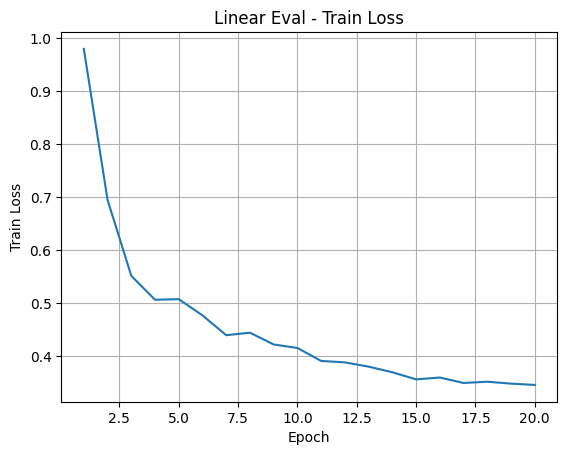

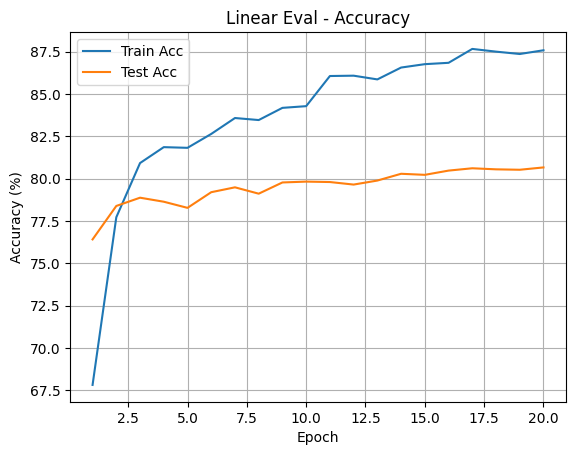

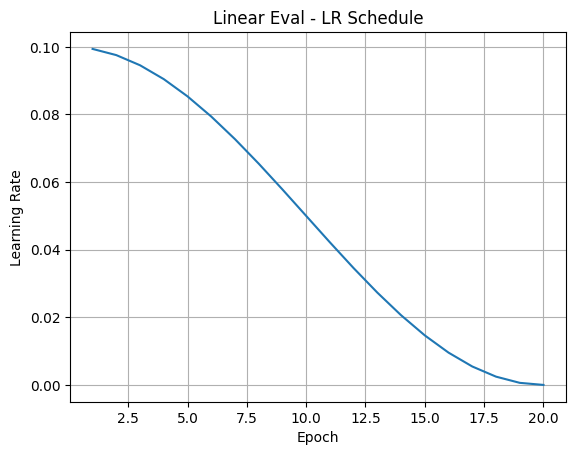

In [7]:
epochs = hist["epoch"]

plt.figure()
plt.plot(epochs, hist["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Linear Eval - Train Loss")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, hist["train_acc"], label="Train Acc")
plt.plot(epochs, hist["test_acc"], label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Linear Eval - Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, hist["lr"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Linear Eval - LR Schedule")
plt.grid(True)
plt.show()

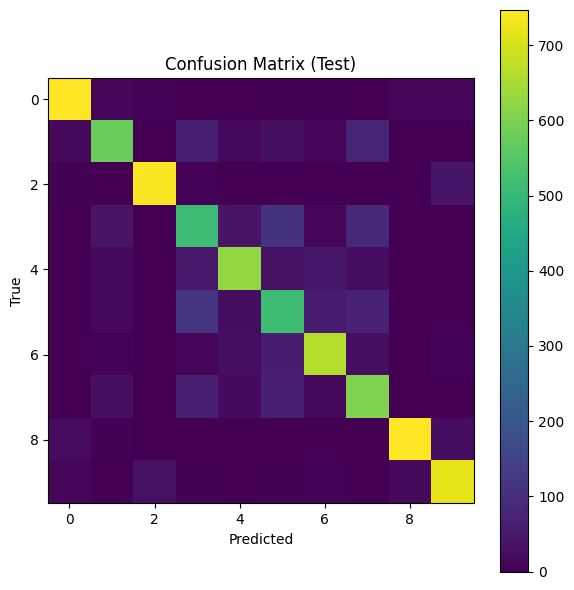

In [8]:
@torch.no_grad()
def confusion_matrix(backbone, clf, loader, num_classes=10):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    backbone.eval()
    clf.eval()
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        if device.type == "cuda":
            x = x.contiguous(memory_format=torch.channels_last)
        f = backbone(x)
        logits = clf(f)
        pred = logits.argmax(dim=1)
        for t, p in zip(y.view(-1), pred.view(-1)):
            cm[t.long(), p.long()] += 1
    return cm

cm = confusion_matrix(backbone, clf, test_loader, num_classes=10).cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()